# WCC: a dithered deep-field stack (cosmology)

Deep extragalactic fields are built from many dithered exposures. This notebook renders five dithered
90 s WCC frames of a COSMOS-like pointing with `wcc_sim`, including analytic Sersic galaxies and faint
injected point sources, and asks **how the signal-to-noise of a faint source grows when the frames are
registered and co-added.**

Install: [repository setup](../../README.md); browse the [gallery index](../README.md).

**At a glance** · Advanced · Package: `wcc_sim + wcc_phot`

- **Question:** the bold science question above; aim for one observing decision from the main comparison plot.
- **Prerequisite:** installed [gallery environment](../../README.md), basic Python and magnitudes/SNR.
- **Cost:** image arrays plus intermediates can exceed 1 GB; run alone and restart the kernel afterward.
- **First edit:** the Parameters cell below. Restart Kernel and Run All after each change.
- **Output:** plotted comparison plus printed achieved metrics/status.
- **Caveat:** recovery against a simplified simulator is not a calibrated observing-performance forecast.

Section introductions describe the original defaults; the Parameters cell and current outputs are authoritative after edits.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from wcc_sim import simulate_field, SersicComponent
from wcc_sim.catalog import query_gaia

## Parameters
Change these inputs first; leave the calculation cells intact.


In [2]:
FRAME_TIME = 90.0          # seconds
DITHER_STEP = 40           # integer pixels; keep <= 40 for this injection geometry
APERTURE_RADIUS = 6        # pixels


## 1. Scene: Gaia stars, two galaxies, and faint injected sources

COSMOS (RA 150.1, Dec +2.2) is nearly empty of Gaia stars in a 2048 px (35") subarray, so we add a disk
and a bulge galaxy as `SersicComponent`s and inject point sources at G = 21 to 27 in 1 mag steps through
the catalog table; the faint end is there to measure the stack's 5 sigma depth directly. Injected rows
are tracked by their exact `source_id` (Gaia IDs are ~1e18, so a `source_id >= 100` cut would count the
real star too). Offsets in RA are scaled by 1/cos(dec).

In [3]:
RA, DEC = 150.1, 2.2
PIX = 16.87e-3 / 3600                       # one IMX455 pixel in degrees
dRA = PIX / np.cos(np.radians(DEC))         # one pixel of RA offset, cos(dec)-corrected
cat = query_gaia(RA, DEC, radius_arcsec=40, mag_limit=21.0, cache_dir="gaia_cache")
injected = {}                               # source_id -> injected G
for i, g in enumerate(range(21, 28)):
    row = {k: np.nan for k in cat.colnames}
    row.update(source_id=100 + i, ra=RA + (-450 + 150 * i) * dRA, dec=DEC + 300 * PIX, phot_g_mean_mag=g)
    cat.add_row(row); injected[100 + i] = g
galaxies = [SersicComponent(RA + 300 * dRA, DEC - 200 * PIX, n=1, r_eff_arcsec=1.5, ellip=0.4, pa_deg=30, total_mag=19),
            SersicComponent(RA - 250 * dRA, DEC - 350 * PIX, n=4, r_eff_arcsec=0.8, total_mag=20, template="K3III")]
n_inj = np.isin(cat["source_id"], list(injected)).sum()
print(f"{len(cat)} catalog rows ({n_inj} injected: G = {list(injected.values())}), {len(galaxies)} galaxies")

8 catalog rows (7 injected: G = [21, 22, 23, 24, 25, 26, 27]), 2 galaxies


## 2. Five dithered frames

Integer-pixel dithers so the co-add below needs no resampling. Rounding the commanded offsets does not
prove the frames are registered to whole pixels, so the shift of one source between each frame's `CAT`
positions is printed with its fraction.

In [4]:
dithers = [(0, 0), (DITHER_STEP, 0), (0, DITHER_STEP), (DITHER_STEP, DITHER_STEP), (DITHER_STEP // 2, DITHER_STEP // 2)]           # pixels
frames = [simulate_field(RA + dx * dRA, DEC + dy * PIX, sensorfilter="zwo:r", focus=0, exptime=FRAME_TIME,
                         seed=k, shape=(2048, 2048), catalog=cat, extended_sources=galaxies)
          for k, (dx, dy) in enumerate(dithers)]
hdul = frames[0].to_hdulist()
hdul.info()
print(f"saturated pixels in frame 0: {int(frames[0].saturation_mask.sum())}")

def pos(f, sid):
    r = f.catalog[f.catalog["source_id"] == sid][0]
    return float(r["x"]), float(r["y"])

ref = frames[0].catalog
x0, y0 = pos(frames[0], 100)
shifts = [(pos(f, 100)[0] - x0, pos(f, 100)[1] - y0) for f in frames]
ipix = [(int(round(dx)), int(round(dy))) for dx, dy in shifts]
print("measured shift of source 100 (px):", ", ".join(f"({dx:+.3f}, {dy:+.3f})" for dx, dy in shifts))
print("largest deviation from an integer pixel:", f"{max(abs(v - round(v)) for s in shifts for v in s):.3f} px")
assert max(abs(v-round(v)) for s in shifts for v in s) < 0.01, "Subpixel registration requires resampling, unsupported in this example"


Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SCI           1 PrimaryHDU      62   (2048, 2048)   float32   
  1  SATMASK       1 ImageHDU         8   (2048, 2048)   uint8   
  2  CAT           1 BinTableHDU     50   8R x 16C   ['K', 'D', 'D', 'E', 'E', 'E', 'D', 'D', 'D', 'E', 'D', 'D', '3A', 'D', 'L', 'L']   
  3  CLEAN         1 ImageHDU         9   (2048, 2048)   float32   


saturated pixels in frame 0: 0
measured shift of source 100 (px): (+0.000, +0.000), (+40.002, +0.000), (-0.000, -40.002), (+40.002, -40.002), (+20.001, -20.001)
largest deviation from an integer pixel: 0.002 px


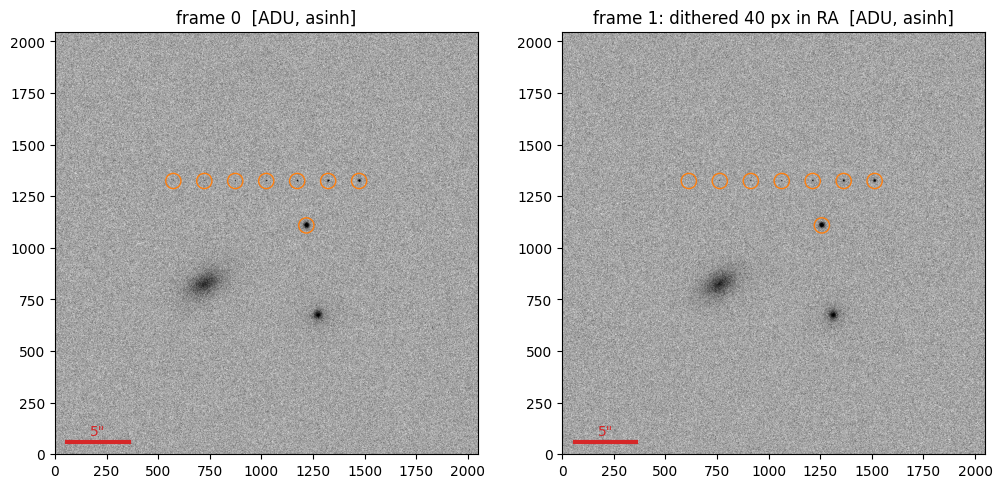

In [5]:
def scalebar(ax, arcsec=5, x=60, y=60):
    n = arcsec * 1000 / frames[0].params["plate_scale_mas"]
    ax.plot([x, x + n], [y, y], color="C3", lw=3); ax.text(x + n / 2, y + 30, f'{arcsec}"', color="C3", ha="center")

shared_norm = simple_norm(frames[0].image_adu, "asinh", percent=99.5)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
for ax, f, t in zip(axes, frames[:2], ("frame 0", f"frame 1: dithered {DITHER_STEP} px in RA")):
    ax.imshow(f.image_adu, origin="lower", cmap="gray_r", norm=shared_norm)
    inn = np.asarray(f.catalog["in_image"], bool)
    ax.scatter(f.catalog["x"][inn], f.catalog["y"][inn], s=120, facecolors="none", edgecolors="C1")
    scalebar(ax); ax.set_title(f"{t}  [ADU, asinh]")
plt.show()

## 3. Register on the CAT positions and co-add

The integer shifts measured above register the frames. `np.roll` would wrap one detector edge into the
opposite edge, so `shift` moves the data and a coverage mask together without wrapping, and pixels not
covered by all five frames are excluded from the co-add.

162240 of 4194304 pixels are not covered by all 5 frames and are excluded


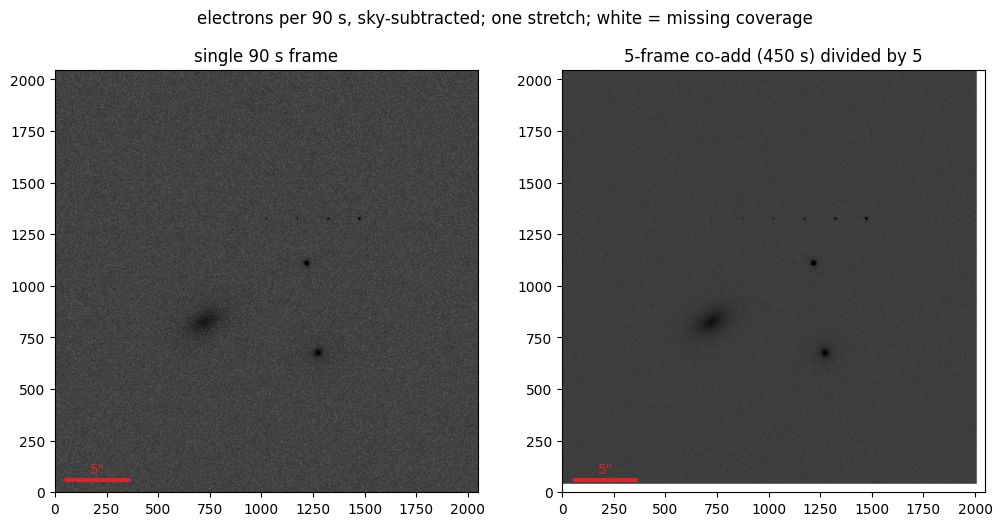

In [6]:
def shift(img, dx, dy):
    """Shift img so that pixel (x + dx, y + dy) lands on (x, y), without wrapping; returns image and coverage."""
    ny, nx = img.shape
    out = np.zeros_like(img); cov = np.zeros(img.shape, bool)
    ys, yd = (slice(dy, ny), slice(0, ny - dy)) if dy >= 0 else (slice(0, ny + dy), slice(-dy, ny))
    xs, xd = (slice(dx, nx), slice(0, nx - dx)) if dx >= 0 else (slice(0, nx + dx), slice(-dx, nx))
    out[yd, xd] = img[ys, xs]; cov[yd, xd] = True
    return out, cov

shifted = []
for f, (dx, dy) in zip(frames, ipix):
    clean = np.where(f.saturation_mask, np.nan, f.image_e)
    moved, covered = shift(clean - np.nanmedian(clean), dx, dy)
    moved[~covered] = np.nan
    shifted.append((moved, covered))
stack = np.sum([s for s, _ in shifted], axis=0)
cov = np.sum([m for _, m in shifted], axis=0)
stack[cov < len(frames)] = np.nan
print(f"{int((cov < len(frames)).sum())} of {cov.size} pixels are not covered by all {len(frames)} frames and are excluded")

single = shifted[0][0]
norm = simple_norm(single, "asinh", percent=99.5)                    # one stretch for both panels
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
for ax, img, t in zip(axes, (single, stack / len(frames)), (f"single {FRAME_TIME:g} s frame", f"{len(frames)}-frame co-add ({FRAME_TIME*len(frames):g} s) divided by {len(frames)}")):
    ax.imshow(img, origin="lower", cmap="gray_r", norm=norm)
    scalebar(ax); ax.set_title(t)
fig.suptitle(f"electrons per {FRAME_TIME:g} s, sky-subtracted; one stretch; white = missing coverage")
plt.show()

## 4. SNR of the injected sources versus number of co-added frames, and the measured depth

Aperture SNR (r = 6 px, background from a 15-40 px annulus) for the G = 21-23 sources after 1 to 5
frames, then the 5 sigma crossing of the G = 21-27 sequence in one frame and in the full stack. All
injected sources sit more than 500 px from every edge, so partial stacks are fully covered there.
This short estimator subtracts the local annulus mean and includes its sampling variance. It approximates source Poisson variance with the positive measured flux; it is not a variance-map reduction. Saturated, uncovered or non-finite apertures are rejected. One injection at each magnitude is **not a completeness experiment**.


G = 21: SNR 106.3 in 1 frame -> 238.9 in 5 frames (ratio 2.25, sqrt(5) = 2.24)
G = 22: SNR 63.4 in 1 frame -> 141.5 in 5 frames (ratio 2.23, sqrt(5) = 2.24)


G = 23: SNR 34.2 in 1 frame -> 78.4 in 5 frames (ratio 2.29, sqrt(5) = 2.24)


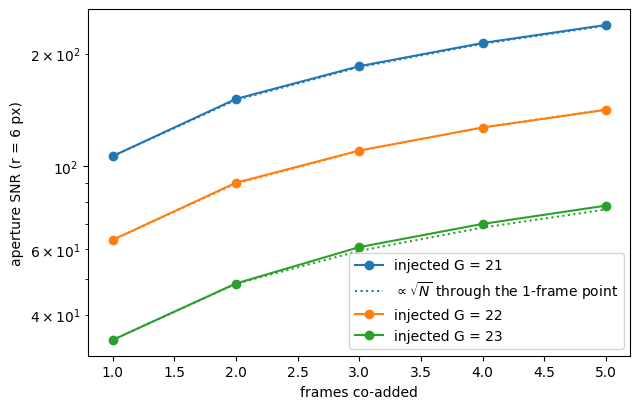

1 frame (90 s)          : SNR G21=106.3 G22= 63.4 G23= 34.2 G24= 17.7 G25=  7.6 G26=  2.8 G27=  4.1  -> no valid crossing (nonpositive/nonfinite/irregular/unbracketed)
5-frame stack (450 s)   : SNR G21=238.9 G22=141.5 G23= 78.4 G24= 37.4 G25= 17.4 G26=  6.7 G27=  4.3  -> 5 sigma injection crossing G = 26.64


In [7]:
yy, xx = np.indices(stack.shape)
r_ap = APERTURE_RADIUS                                                             # px, ~ 0.1"

def aperture_snr(img, x, y):
    rr = np.hypot(xx - x, yy - y)
    ap, ann = rr < r_ap, (rr > 15) & (rr < 40)
    if not (np.isfinite(img[ap]).all() and np.isfinite(img[ann]).all()) or ann.sum() < 2:
        return np.nan
    background = np.mean(img[ann])
    src = np.sum(img[ap] - background)
    variance = np.var(img[ann], ddof=1)
    # Empirical background variance plus uncertainty of its estimated mean.
    if not np.isfinite(src) or src <= 0:
        return np.nan
    return src / np.sqrt(src + variance * ap.sum() * (1 + ap.sum() / ann.sum()))

def crossing(g, snr, target=5):
    """Guarded crossing of this injection sequence, not a completeness depth."""
    g, snr = np.asarray(g), np.asarray(snr)
    if (len(g) < 2 or not np.all(np.isfinite(snr)) or np.any(snr <= 0)
            or np.any(np.diff(g) <= 0) or np.any(np.diff(snr) >= 0)
            or not snr[-1] < target < snr[0]):
        return np.nan
    return np.interp(np.log10(target), np.log10(snr[::-1]), g[::-1])

n_frames = np.arange(1, len(frames) + 1)
fig, ax = plt.subplots(figsize=(7, 4.5))
for sid in (100, 101, 102):
    x, y = pos(frames[0], sid)
    partial = np.zeros_like(stack); snr = []
    for s, _ in shifted:
        partial += s
        snr.append(aperture_snr(partial, x, y))
    l, = ax.plot(n_frames, snr, "o-", label=f"injected G = {injected[sid]}")
    ax.plot(n_frames, snr[0] * np.sqrt(n_frames), ":", color=l.get_color(),
            label="$\\propto\\sqrt{N}$ through the 1-frame point" if sid == 100 else None)
    print(f"G = {injected[sid]}: SNR {snr[0]:.1f} in 1 frame -> {snr[-1]:.1f} in 5 frames (ratio {snr[-1] / snr[0]:.2f}, sqrt(5) = {np.sqrt(5):.2f})")
ax.set(xlabel="frames co-added", ylabel=f"aperture SNR (r = {r_ap:g} px)", yscale="log"); ax.legend()
plt.show()

g_inj = np.array(list(injected.values()), float)
for label, img in ((f"1 frame ({FRAME_TIME:g} s)", single), (f"{len(frames)}-frame stack ({FRAME_TIME * len(frames):g} s)", stack)):
    snr = np.array([aperture_snr(img, *pos(frames[0], sid)) for sid in injected])
    d = crossing(g_inj, snr)
    print(f"{label:24s}: SNR " + " ".join(f"G{g:.0f}={s:5.1f}" for g, s in zip(g_inj, snr))
          + (f"  -> 5 sigma injection crossing G = {d:.2f}" if np.isfinite(d) else "  -> no valid crossing (nonpositive/nonfinite/irregular/unbracketed)"))

## Reference-run takeaway (original defaults)

**Historical baseline prose:** numerical values below describe the pre-review default run. Use the freshly printed values and plots for current results, especially where this revision corrects an estimator.

Because the WCC background in space is only a few electrons per pixel per frame, faint-source SNR is set by
source photons and read noise, and integer-pixel dithers registered on the `CAT` positions (measured shifts
within 0.002 px of whole pixels) co-add almost exactly as sqrt(N): the injected G = 23 source goes from
SNR 34.5 in one 90 s frame to 78.7 in five (ratio 2.28 vs sqrt(5) = 2.24), and G = 21 from 106 to 239.
Measured on the injected G = 21-27 sequence, the 5 sigma point-source depth is G = 25.5 in one 90 s frame
and G = 26.7 in the 450 s stack. The dithers also move the analytic Sersic galaxies and every star onto
different pixels, which is what a real reduction needs to reject detector defects; the price is a border
(4% of the pixels here) that is not covered by all five frames and is excluded from the co-add.

## Try this

1. Set FRAME_TIME to 45. Compare measured SNR gain with sqrt(N).
2. Set APERTURE_RADIUS to 8. Compare the guarded injection crossing and source SNR.

**Extension:** Inject many sources at each magnitude and several positions to estimate completeness.

Bring back one figure, the requested and achieved metric, an observing decision, and the main limitation.
